In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings

warnings.filterwarnings("ignore")

These libraries are used for:

pandas : data handling,
numpy  : numerical operations,
matplotlib and seaborn : EDA and visualization,
sklearn : preprocessing, models and evaluation,
joblib : saving the trained model,

In [3]:
df = pd.read_csv("train.csv")


In [4]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


The dataset contains hourly bike rental information.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


This tells us:

number of rows,
number of columns,
data types,
missing values,
memory usage,

In [7]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


This helps identify:

minimum values,
maximum values,
average values,
standard deviation,
possible unusual values,

In [9]:
 df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


the result contains zeros for all columns, there are no missing values in this version of the dataset.

In [10]:
df.duplicated().sum()

np.int64(0)

the results contains zero duplicate values

In [12]:
df["count"].describe()

,count
count,10886.000000
mean,191.574132
std,181.144454
min,1.000000
25%,42.000000
50%,145.000000
75%,284.000000
max,977.000000


count represents rental demand, so negative values would be invalid.

In [13]:
df["datetime"] = pd.to_datetime(df["datetime"])

print(df["datetime"].min())
print(df["datetime"].max())

2011-01-01 00:00:00
2012-12-19 23:00:00


Machine-learning models cannot directly understand a timestamp such as:

2011-01-01 00:00:00

Therefore, we extract meaningful information from it.

In [15]:
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

df["rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

df["temp_humidity"] = df["temp"] * df["humidity"]

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday,is_weekend,rush_hour,temp_humidity
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,1,0,797.04
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,1,0,721.60
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,1,0,721.60
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,1,0,738.00
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,1,0,738.00


is_weekend:tells the model whether the day is Saturday/Sunday.

rush_hour: captures typical commuting periods.

temp_humidity : allows the model to consider the combined effect of temperature and humidity.

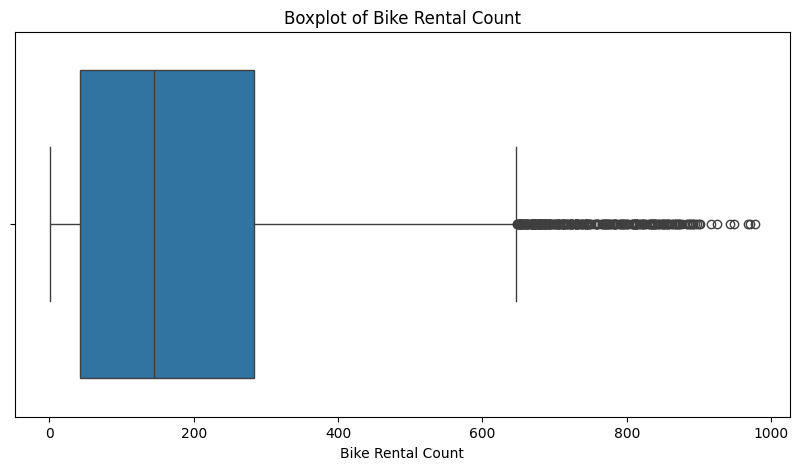

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["count"])

plt.title("Boxplot of Bike Rental Count")
plt.xlabel("Bike Rental Count")

plt.show()

 We will likely see some large values.

However, do not automatically delete them.

High rental counts can be genuine peak-demand observations.

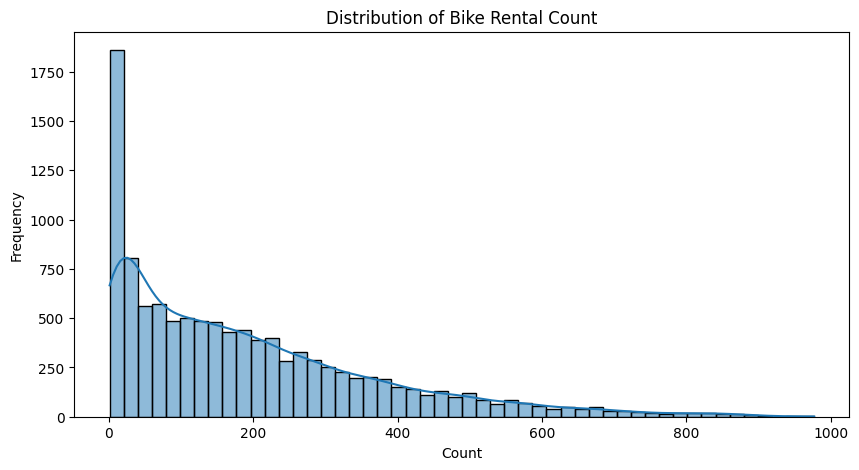

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(df["count"], bins=50, kde=True)

plt.title("Distribution of Bike Rental Count")
plt.xlabel("Count")
plt.ylabel("Frequency")

plt.show()

The target is generally right-skewed.

This means:
many hours have relatively lower demand.
some hours have very high demand.


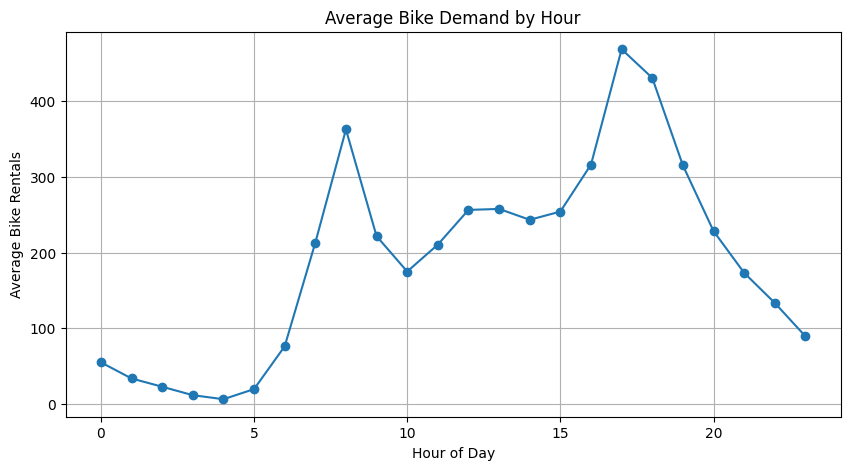

In [18]:
hourly_demand = df.groupby("hour")["count"].mean()

plt.figure(figsize=(10, 5))

hourly_demand.plot(kind="line", marker="o")

plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Rentals")

plt.grid()
plt.show()

This visualization shows how demand changes throughout the day.


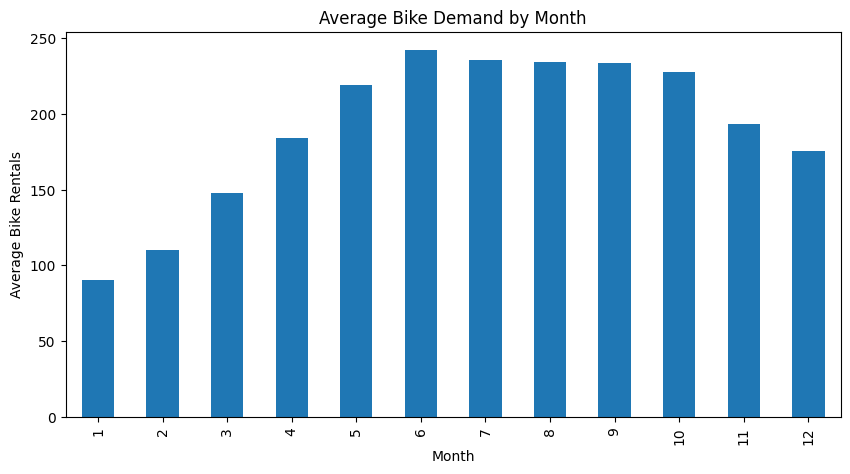

In [19]:
monthly_demand = df.groupby("month")["count"].mean()

plt.figure(figsize=(10, 5))

monthly_demand.plot(kind="bar")

plt.title("Average Bike Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Bike Rentals")

plt.show()

Demand changes across months, indicating seasonal effects.

workingday
0    188.506621
1    193.011873
Name: count, dtype: float64


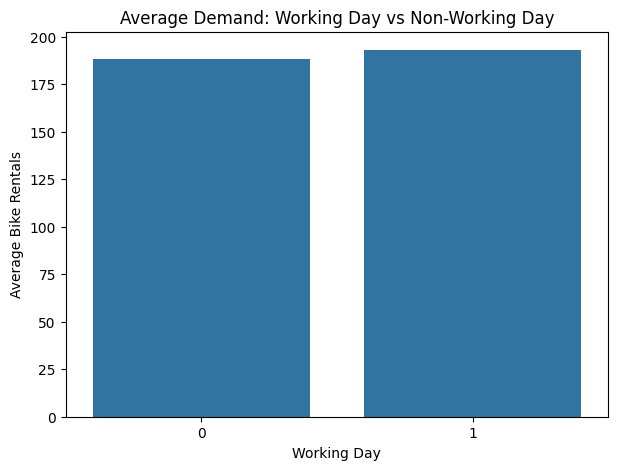

In [20]:
workingday_demand = df.groupby("workingday")["count"].mean()

print(workingday_demand)

plt.figure(figsize=(7, 5))

sns.barplot(x=workingday_demand.index, y=workingday_demand.values)

plt.title("Average Demand: Working Day vs Non-Working Day")
plt.xlabel("Working Day")
plt.ylabel("Average Bike Rentals")

plt.show()

This compares bike demand between:
working day,
non-working day.
 Here, differences indicate that workingday can contribute useful predictive information.

weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64


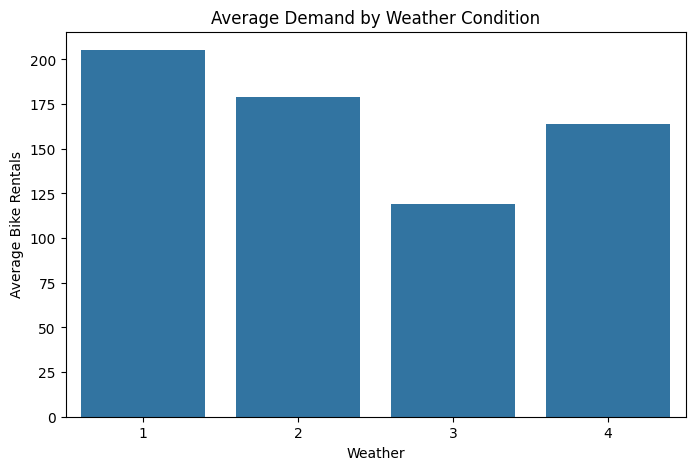

In [21]:
weather_demand = df.groupby("weather")["count"].mean()

print(weather_demand)

plt.figure(figsize=(8, 5))

sns.barplot(x=weather_demand.index, y=weather_demand.values)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Bike Rentals")

plt.show()

Weather conditions can affect people's willingness to use bicycles.

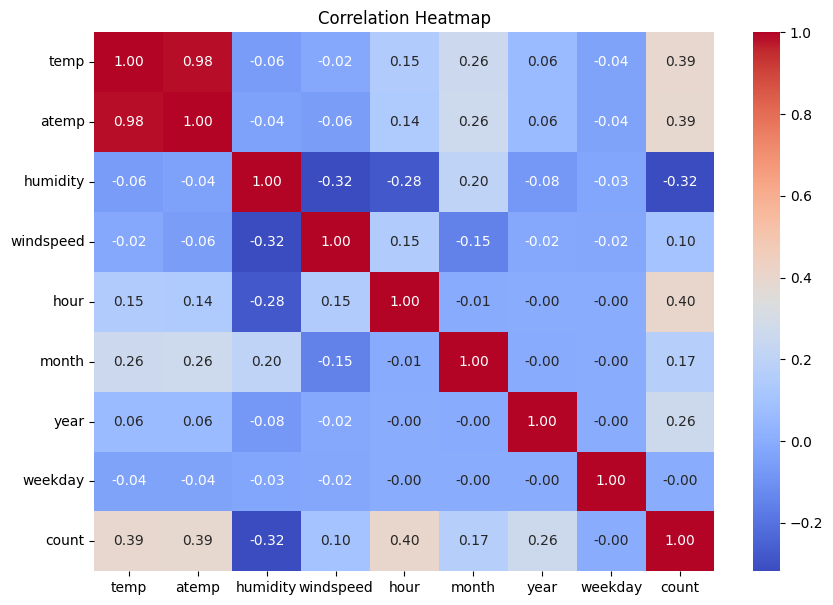

In [22]:
numeric_cols = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "hour",
    "month",
    "year",
    "weekday",
    "count"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation matrix helps identify relationships between numerical variables and the target.

In [23]:
features = [
    "season",
    "holiday",
    "workingday",
    "weather",
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "day",
    "hour",
    "weekday",
    "is_weekend",
    "rush_hour",
    "temp_humidity"
]

X = df[features].copy()
y = df["count"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10886, 16)
y shape: (10886,)


count is the target.

casual and registered cause leakage.

datetime has already been converted into useful features.

In [24]:
categorical_features = [
    "season",
    "holiday",
    "workingday",
    "weather",
    "year",
    "month",
    "day",
    "hour",
    "weekday",
    "is_weekend",
    "rush_hour"
]

numerical_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "temp_humidity"
]

Categorical variables represent groups or categories.

Numerical variables contain continuous numerical measurements.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8708, 16)
Testing data: (2178, 16)


This is more realistic for demand forecasting because future observations should not be used to train the model.

In [28]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features)
    ]
)

this performs:

Missing-value handling,
One-hot encoding,
Numerical scaling.

StandardScaler is particularly important for the linear Ridge model.

In [29]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
MAE : 72.38244733413156
RMSE: 98.92002625925949
R²  : 0.7035419575102764


Ridge Regression is a linear regression method with regularization.
If its performance is lower than tree-based models, this suggests that bike demand has nonlinear relationships that a simple linear model cannot fully capture.

In [30]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 29.954196420359562
RMSE: 46.480834715033154
R²  : 0.9345450300312559


Random Forest can capture nonlinear relationships and interactions.

In [31]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=5,
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting
MAE : 36.30432881710109
RMSE: 54.31425050699557
R²  : 0.9106236998126939


Gradient Boosting builds models sequentially.

Each new tree attempts to improve the errors made by previous trees.

This makes it suitable for complex nonlinear regression problems.

In [32]:
results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Ridge Regression,72.382447,98.920026,0.703542
1,Random Forest,29.954196,46.480835,0.934545
2,Gradient Boosting,36.304329,54.314251,0.910624


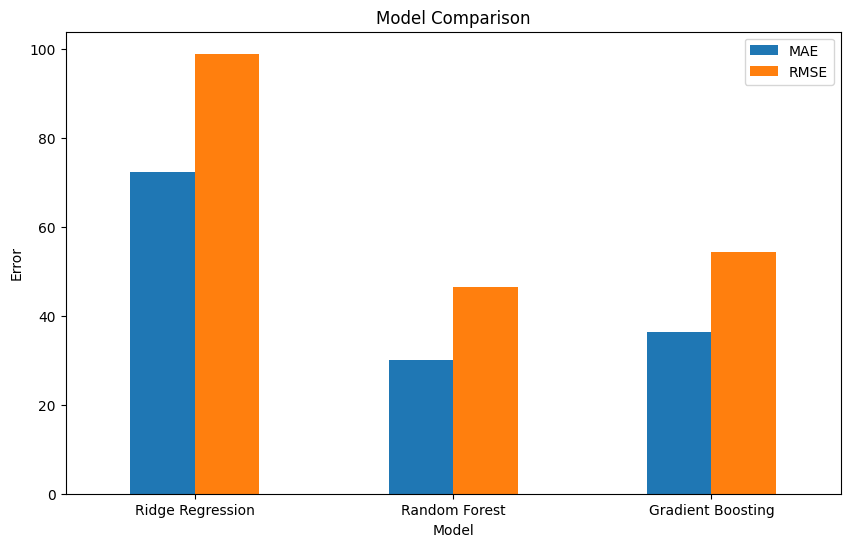

In [33]:
results_plot = results.set_index("Model")

results_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)

plt.show()

This provides a visual comparison of model errors.

In [35]:
final_model = gb_model
final_pred = gb_pred

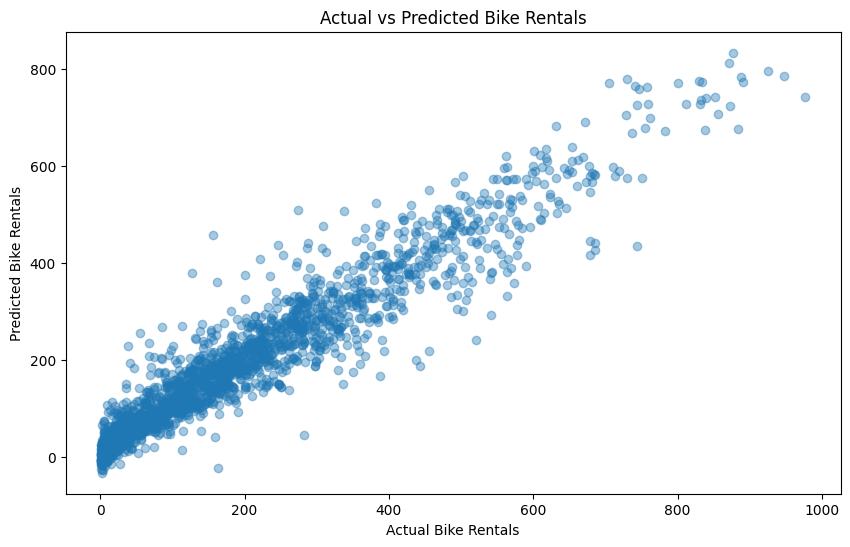

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    final_pred,
    alpha=0.4
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")

plt.show()

If predictions become less accurate for very high demand, that should be mentioned as a limitation.

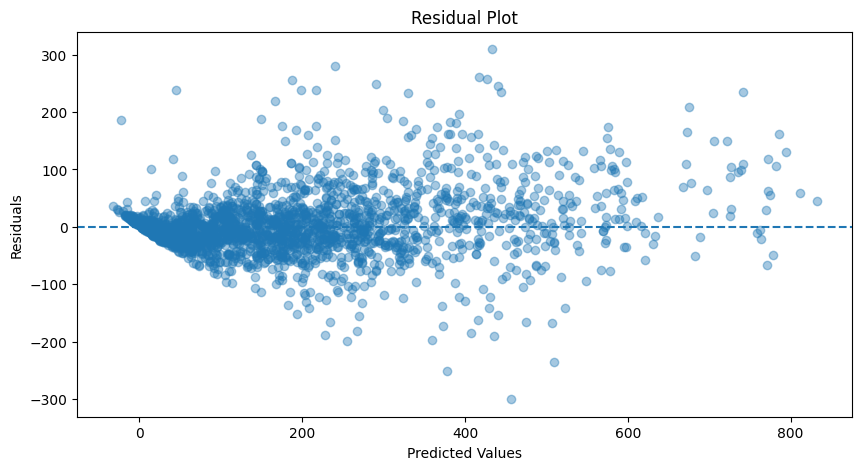

In [37]:
residuals = y_test - final_pred

plt.figure(figsize=(10, 5))

plt.scatter(
    final_pred,
    residuals,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

A good regression model should ideally have residuals distributed around zero without a strong systematic pattern.

In [38]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_pred
})

prediction_df.head(10)

,Actual,Predicted
0,127,166.928143
1,13,23.860338
2,163,175.254994
3,233,234.675576
4,222,200.780691
5,166,175.535142
6,144,156.849708
7,376,327.403445
8,601,630.490057
9,53,77.233216


This lets us directly compare actual bike demand with model predictions.

In [39]:
joblib.dump(final_model, "bike_demand_regression_model.pkl")

print("Model saved successfully.")

Model saved successfully.


The pipeline contains the preprocessing and trained model, so you don't need to manually recreate the preprocessing when making predictions.

In [40]:
loaded_model = joblib.load("bike_demand_regression_model.pkl")

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [41]:
def predict_bike_demand(
    season,
    holiday,
    workingday,
    weather,
    temp,
    atemp,
    humidity,
    windspeed,
    year,
    month,
    day,
    hour,
    weekday
):

    is_weekend = int(weekday >= 5)

    rush_hour = int(
        hour in [7, 8, 9, 16, 17, 18, 19]
    )

    temp_humidity = temp * humidity

    input_data = pd.DataFrame([{
        "season": season,
        "holiday": holiday,
        "workingday": workingday,
        "weather": weather,
        "temp": temp,
        "atemp": atemp,
        "humidity": humidity,
        "windspeed": windspeed,
        "year": year,
        "month": month,
        "day": day,
        "hour": hour,
        "weekday": weekday,
        "is_weekend": is_weekend,
        "rush_hour": rush_hour,
        "temp_humidity": temp_humidity
    }])

    prediction = loaded_model.predict(input_data)[0]

    return max(0, prediction)

In [42]:
prediction = predict_bike_demand(
    season=2,
    holiday=0,
    workingday=1,
    weather=1,
    temp=25,
    atemp=27,
    humidity=50,
    windspeed=10,
    year=2012,
    month=6,
    day=15,
    hour=8,
    weekday=4
)

print("Predicted bike rentals:", round(prediction))

Predicted bike rentals: 561
